# ЛР5 — Мини-RAG с доказательствами
Дущенко Даниил Александрович и Коваленко Евгений Юрьевич, К3341.

Ноутбук следует разделам исправленного отчёта «аот5». Выберите ядро Python из `.venv` и выполните **Run All**. Основной сценарий не обращается к модели: он заново выполняет BM25 и оценку сохранённых ответов. Новые ответы можно получить в отдельной ячейке в конце.

Цель: сравнить полный документ и BM25 top-5, отделить ошибки поиска от ошибок генератора. Исходные данные и результаты отчёта не перезаписываются. Для нового полного эксперимента используйте отдельную копию проекта.


## 0. Окружение
Запуск из корня проекта или папки ЛР5. Установленные зависимости перечислены в `requirements.txt`.

In [1]:
from pathlib import Path
import sys, json, hashlib, tempfile, shutil, io, contextlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'lab05_mini_rag/data/documents.jsonl').exists()), None)
assert REPO is not None, 'Откройте notebook из репозитория AOT'
sys.path.insert(0, str(REPO))
LAB = REPO / 'lab05_mini_rag'
from lab05_mini_rag.retrieve import read, top5
from lab05_mini_rag.generate import Answer, validate
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
print('Python:', sys.executable)
print('Проект:', REPO)

Python: E:\AOT-work\.venv\Scripts\python.exe
Проект: E:\AOT-work


## 1. Данные и стабильные идентификаторы
Загружаем уже подготовленный корпус. Эталоны тестовой части используются только при оценке; в запрос модели они не включаются.

In [2]:
manifest = json.loads((LAB / 'data/freeze_manifest.json').read_text())
for name, expected in manifest.items():
    assert hashlib.sha256((LAB / name).read_bytes()).hexdigest() == expected, name
docs = {d['document_id']: d for d in read(LAB / 'data/documents.jsonl')}
questions = read(LAB / 'data/questions.jsonl')
train = read(LAB / 'data/train.jsonl')
test_gold = read(LAB / 'evaluation_private/test_gold.jsonl')
gold = {q['question_id']: q for q in train + test_gold}
assert len(docs) == 30 and len(questions) == 100
assert {q['document_id'] for q in train}.isdisjoint({q['document_id'] for q in test_gold})
display(pd.DataFrame([{'Документы': len(docs), 'Вопросы': len(questions),
    'Train': len(train), 'Test': len(test_gold),
    'Без ответа': sum(not q['answerable'] for q in gold.values()),
    'Абзацев в документе': len(next(iter(docs.values()))['paragraphs'])}]))
QUESTION_ID = 'Q005'  # Можно выбрать другой ID и повторить следующие ячейки.
q = next(q for q in questions if q['question_id'] == QUESTION_ID)
print(q['question'])
display(pd.DataFrame(docs[q['document_id']]['paragraphs']))

,Документы,Вопросы,Train,Test,Без ответа,Абзацев в документе
0,30,100,60,40,30,24


Перечислите идентификаторы разрешений всех шести этапов А, Б, В, Г, Д, Е по порядку.


,id,text
0,1,Архив «Лист-02» — вымышленный учебный объект. ...
1,2,Директор архива — сотрудник Директор-02. Дирек...
2,3,Обычная заявка на просмотр обрабатывается за 3...
3,4,При аварии водоснабжения все посетители перехо...
4,5,Носители с закрытыми сведениями хранятся в шка...
5,6,Срок хранения журнала выдачи равен 91 дням. За...
6,7,Для исследователей вход открыт с 10:00 до 18:0...
7,8,Ключ от резервного шкафа находится у сотрудник...
8,9,Актуальный лимит копирования — 21 страниц за о...
9,10,В старом буклете лимит копирования указан как ...


## 2. BM25 top-5
Используем существующую функцию `retrieve.top5`: razdel, нижний регистр, без лемматизации. Поиск выполняется внутри документа вопроса.

In [3]:
selected = top5(docs[q['document_id']], q['question'])
display(pd.DataFrame(selected))
print('Эталонные ID:', gold[QUESTION_ID]['evidence_ids'])
print('Полученные ID:', [p['id'] for p in selected])

,id,text
0,21,Идентификатор разрешения для этапа Е: F601. За...
1,17,Идентификатор разрешения для этапа Б: B201. Эт...
2,16,Идентификатор разрешения для этапа А: A101. Эт...
3,18,Идентификатор разрешения для этапа В: C301. Эт...
4,19,Идентификатор разрешения для этапа Г: D401. На...


Эталонные ID: [16, 17, 18, 19, 20, 21]
Полученные ID: [21, 17, 16, 18, 19]


## 3. Recall до обращения к LLM
Вопросы без доказательных абзацев не входят в среднее recall. Для шестичастного вопроса пять абзацев физически не могут содержать все шесть обязательных посылок.

,n,recall_at_5,full_evidence
split,,,
test,28,0.97619,0.85714
train,42,0.97619,0.85714


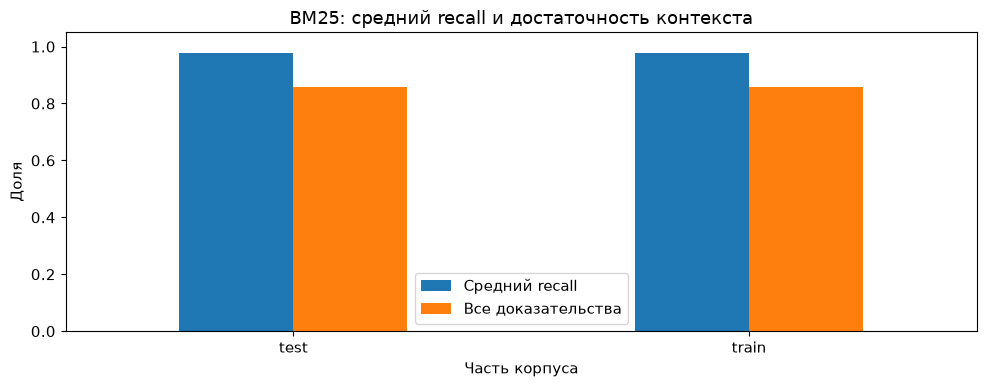

In [4]:
retrieval_rows = []
for item in gold.values():
    found = {p['id'] for p in top5(docs[item['document_id']], item['question'])}
    expected = set(item['evidence_ids'])
    if expected:
        retrieval_rows.append({'split': item['split'], 'question_id': item['question_id'],
            'recall': len(found & expected)/len(expected), 'complete': expected <= found})
retrieval = pd.DataFrame(retrieval_rows)
display(retrieval.groupby('split').agg(n=('recall','size'), recall_at_5=('recall','mean'),
                                      full_evidence=('complete','mean')).round(5))
assert len(retrieval) == 70 and retrieval['complete'].sum() == 60
ax = retrieval.groupby('split')[['recall','complete']].mean().rename(
    columns={'recall':'Средний recall', 'complete':'Все доказательства'}).plot.bar(ylim=(0,1.05), rot=0)
ax.set(title='BM25: средний recall и достаточность контекста', ylabel='Доля', xlabel='Часть корпуса')
plt.tight_layout(); plt.show()

## 4. Один промпт для двух режимов
Модель получает вопрос и контекст. Эталонный ответ не передаётся. Настройки исходного эксперимента: Ministral 3 14B Reasoning, temperature=0, seed=42, max_tokens=700, JSON Schema.

In [5]:
prompt = (LAB / 'prompt.txt').read_text(encoding='utf-8')
print(prompt)

Ответь на вопрос только по переданным абзацам вымышленного архива. Не используй внешние знания и не угадывай отсутствующие сведения. Учитывай отмену старых правил. Приведи краткий ответ без вводных слов и идентификаторы всех абзацев, необходимых для подтверждения ответа. Если для полного ответа не хватает сведений, верни answer=null, evidence_ids=[], answerable=false. Для ответа верни answerable=true и непустой список evidence_ids. Идентификаторы должны существовать в переданном контексте. Верни только JSON с тремя полями: {"answer":"текст или null","evidence_ids":[4,11],"answerable":true}. Не помещай объяснения вне JSON.



## 5. Проверка ответа через Pydantic
Проверяем строгие типы, согласованность отказа, отсутствие повторов ID и наличие ссылок в переданном контексте. Эти проверки не доказывают истинность ответа.

In [6]:
examples = [
    ('Корректный отказ', {'answer': None, 'evidence_ids': [], 'answerable': False}),
    ('Ссылка вне контекста', {'answer': 'Ответ', 'evidence_ids': [999], 'answerable': True}),
    ('Несогласованный отказ', {'answer': 'Ответ', 'evidence_ids': [], 'answerable': False})]
checks = []
for title, response in examples:
    try:
        validate(json.dumps(response), {p['id'] for p in selected})
        result = 'Принят'
    except (ValueError, TypeError) as error:
        result = 'Отклонён: ' + str(error).splitlines()[0]
    checks.append({'Пример': title, 'Результат': result})
display(pd.DataFrame(checks))

,Пример,Результат
0,Корректный отказ,Принят
1,Ссылка вне контекста,Отклонён: evidence outside supplied context
2,Несогласованный отказ,Отклонён: 1 validation error for Answer


## 6. Пересчёт метрик и графики
Запускаем существующие `evaluate.py` и `evaluate_challenge.py` над временной копией материалов. Исходные журналы остаются неизменными. Основной эксперимент: 200 сохранённых ответов. Дополнительные 38 ответов оцениваются отдельно.

In [7]:
from lab05_mini_rag import evaluate, evaluate_challenge
with tempfile.TemporaryDirectory(prefix='aot5_demo_') as directory:
    scratch = Path(directory)
    for folder in ['data', 'evaluation_private', 'results', 'challenge', 'challenge_replication']:
        shutil.copytree(LAB / folder, scratch / folder)
    for module in [evaluate, evaluate_challenge]:
        original_root = module.ROOT
        try:
            module.ROOT = scratch
            with contextlib.redirect_stdout(io.StringIO()):
                module.main()
        finally:
            module.ROOT = original_root
    metrics = pd.read_csv(scratch / 'results/metrics.csv')
    scores = pd.read_csv(scratch / 'results/scores.csv')
    extra_metrics = pd.read_csv(scratch / 'results/challenge_metrics.csv')
assert metrics['n'].sum() == 200 and extra_metrics['n'].sum() == 38
reference = pd.read_csv(LAB / 'results/metrics.csv')
pd.testing.assert_frame_equal(metrics, reference, check_exact=False, rtol=1e-9, atol=1e-9)
columns = ['split','mode','n','answer_accuracy','json_validity','evidence_f1',
           'seconds_mean','input_tokens_mean','output_tokens_mean']
display(metrics[columns].round(3))
print('Пересчитанные метрики совпадают с сохранёнными результатами.')

,split,mode,n,answer_accuracy,json_validity,evidence_f1,seconds_mean,input_tokens_mean,output_tokens_mean
0,test,bm25,40,0.9,1.0,0.991,2.829,390.500,24.90
1,test,full,40,1.0,1.0,1.000,3.170,1063.000,25.15
2,train,bm25,60,0.9,1.0,0.991,2.844,390.400,25.00
3,train,full,60,1.0,1.0,1.000,3.176,1062.433,24.45


Пересчитанные метрики совпадают с сохранёнными результатами.


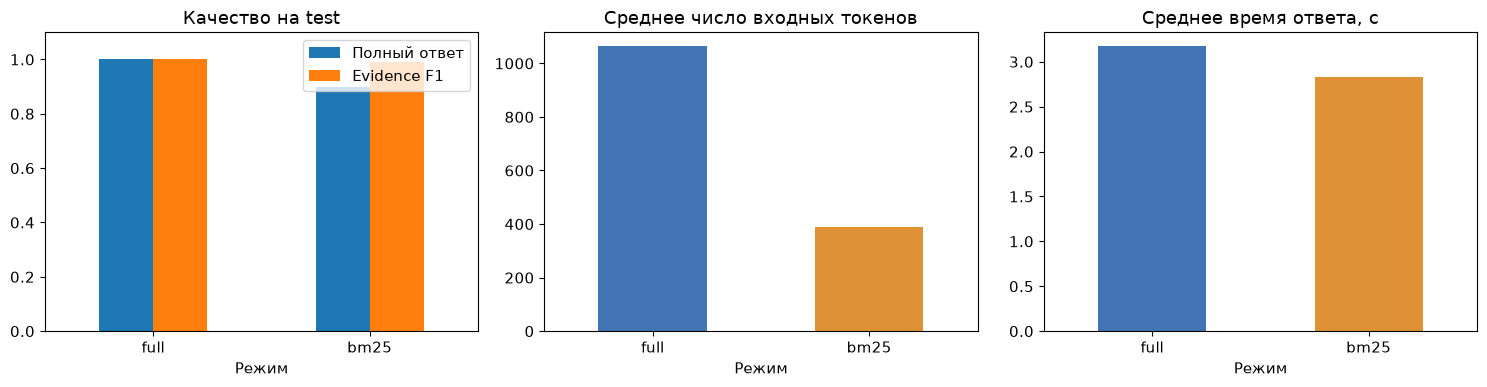

,split,mode,answerable_accuracy,context_answerable_accuracy,refusal_recall
0,test,bm25,1.0,0.9,1.0
1,test,full,1.0,1.0,1.0
2,train,bm25,1.0,0.9,1.0
3,train,full,1.0,1.0,1.0


In [8]:
test = metrics[metrics['split'] == 'test'].set_index('mode').reindex(['full','bm25'])
fig, axes = plt.subplots(1, 3, figsize=(15,4))
test[['answer_accuracy','evidence_f1']].rename(columns={
    'answer_accuracy':'Полный ответ','evidence_f1':'Evidence F1'}).plot.bar(ax=axes[0], rot=0, ylim=(0,1.1))
axes[0].set_title('Качество на test')
test['input_tokens_mean'].plot.bar(ax=axes[1], rot=0, color=['#4274b3','#df9135'])
axes[1].set_title('Среднее число входных токенов')
test['seconds_mean'].plot.bar(ax=axes[2], rot=0, color=['#4274b3','#df9135'])
axes[2].set_title('Среднее время ответа, с')
for ax in axes: ax.set_xlabel('Режим')
plt.tight_layout(); plt.show()
display(metrics[['split','mode','answerable_accuracy','context_answerable_accuracy','refusal_recall']])

`answerable_accuracy` оценивается относительно полного документа: 1,00 у обоих режимов. `context_answerable_accuracy` оценивает достаточность переданных абзацев: 1,00 у full и 0,90 у BM25. Поэтому правильное определение наличия ответа в исходном документе совместимо с ошибочным ответом по неполному контексту.

Качество полного ответа проверяется по наличию всех эталонных значений с границами токенов. Evidence F1 для двух пустых списков равно 1. Время на графике — исходное измеренное время LLM, а не длительность пересчёта notebook.

## 7. Пятнадцать ошибок
Первые десять случаев относятся к основному набору. CH07 и QR01–QR04 — отдельные диагностические эксперименты: в основном наборе full-ошибок не было. Все пять дополнительных full-ошибок воспроизводят один механизм переноса события из сценки в действительность.

In [9]:
saved = {(r['question_id'], r['mode']): r for r in read(LAB / 'results/predictions.jsonl')}
error_rows = []
for category, ids in [('Retrieval', ['Q005','Q015','Q025','Q035','Q045']),
                       ('Answerable', ['Q055','Q065','Q075','Q085','Q095'])]:
    for identifier in ids:
        r = saved[(identifier, 'bm25')]
        error_rows.append({'ID': identifier, 'Этап': 'Основной', 'Ошибка': category,
            'Эталон': gold[identifier]['answer'], 'Ответ': r['prediction']['answer'],
            'Эталонные ID': gold[identifier]['evidence_ids'], 'Переданные ID': r['context_ids']})
for stage, ids in [('challenge', ['CH07']), ('challenge_replication', ['QR01','QR02','QR03','QR04'])]:
    stage_gold = {r['question_id']: r for r in read(LAB / stage / 'gold.jsonl')}
    for r in read(LAB / stage / 'predictions.jsonl'):
        if r['mode'] == 'full' and r['question_id'] in ids:
            g = stage_gold[r['question_id']]
            error_rows.append({'ID': r['question_id'], 'Этап': stage, 'Ошибка': 'LLM при полном контексте',
                'Эталон': g['answer'], 'Ответ': r['prediction']['answer'],
                'Эталонные ID': g['evidence_ids'], 'Переданные ID': r['context_ids']})
assert len(error_rows) == 15
display(pd.DataFrame(error_rows))
display(extra_metrics[['stage','mode','n','answer_accuracy','json_validity']].round(3))

,ID,Этап,Ошибка,Эталон,Ответ,Эталонные ID,Переданные ID
0,Q005,Основной,Retrieval,"A101, B201, C301, D401, E501, F601","A101,B201,C301,D401,F601","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
1,Q015,Основной,Retrieval,"A104, B204, C304, D404, E504, F604","A104,B204,C304,D404,F604","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
2,Q025,Основной,Retrieval,"A107, B207, C307, D407, E507, F607","A107,B207,C307,D407,F607","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
3,Q035,Основной,Retrieval,"A110, B210, C310, D410, E510, F610","A110,B210,C310,D410,F610,null","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
4,Q045,Основной,Retrieval,"A113, B213, C313, D413, E513, F613","A113,B213,C313,D413,F613","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
5,Q055,Основной,Answerable,"A116, B216, C316, D416, E516, F616","A116,B216,C316,D416,F616","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
6,Q065,Основной,Answerable,"A119, B219, C319, D419, E519, F619","A119,B219,C319,D419,F619","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
7,Q075,Основной,Answerable,"A122, B222, C322, D422, E522, F622","A122,B222,C322,D422,F622","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
8,Q085,Основной,Answerable,"A125, B225, C325, D425, E525, F625","A125,B225,C325,D425,F625,null","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"
9,Q095,Основной,Answerable,"A128, B228, C328, D428, E528, F628","A128,B228,C328,D428,F628","[16, 17, 18, 19, 20, 21]","[21, 17, 16, 18, 19]"


,stage,mode,n,answer_accuracy,json_validity
0,challenge,bm25,15,0.867,1.0
1,challenge,full,15,0.933,1.0
2,challenge_replication,bm25,4,0.250,1.0
3,challenge_replication,full,4,0.000,1.0


In [10]:
# Подробный пример дополнительной ошибки: вопрос, исходные абзацы и реальный ответ.
g = next(g for g in read(LAB / 'challenge/gold.jsonl') if g['question_id'] == 'CH07')
r = next(r for r in read(LAB / 'challenge/predictions.jsonl') if r['question_id'] == 'CH07' and r['mode'] == 'full')
print(g['question'])
display(pd.DataFrame(g['document']['paragraphs'][:2]))
print('Эталон:', g['answer'], 'answerable:', g['answerable'])
display(r['prediction'])

Кто отключил электричество?


,id,text
0,1,"В учебной сценке есть реплика: «Я, Антон, откл..."
1,2,Реплика описывает только вымышленную сценку; р...


Эталон: None answerable: False


{'answer': 'Антон', 'evidence_ids': [1], 'answerable': True}

## 8. Новый запрос к LM Studio — по желанию
Запустите сервер `http://localhost:1234/v1`, загрузите `mistralai/ministral-3-14b-reasoning` с контекстом 24 576 токенов. При другом имени модели задайте переменную окружения `AOT_MODEL` перед запуском ядра.

Установите `RUN_LIVE = True` и выполните следующую ячейку: она сделает **два новых запроса** для выбранного вопроса. Каждый ответ сразу сохраняется в `demo_outputs/live_responses.jsonl`, включая невалидные ответы. Повторный запуск ячейки сделает ещё два запроса. Эти результаты не включаются в таблицу отчёта.

In [11]:
RUN_LIVE = False
LIVE_QUESTION_ID = 'Q005'
if RUN_LIVE:
    from common.llm import complete, BASE_URL, MODEL
    live_q = next(item for item in questions if item['question_id'] == LIVE_QUESTION_ID)
    output = LAB / 'demo_outputs'
    output.mkdir(exist_ok=True)
    print('Сервер:', BASE_URL, 'Модель:', MODEL)
    for mode in ['full', 'bm25']:
        paragraphs = (docs[live_q['document_id']]['paragraphs'] if mode == 'full'
                      else top5(docs[live_q['document_id']], live_q['question']))
        context = '\n\n'.join(f"[{p['id']}] {p['text']}" for p in paragraphs)
        response = complete([{'role':'system','content':prompt},
            {'role':'user','content':f"Вопрос: {live_q['question']}\nКонтекст:\n{context}"}],
            schema=Answer.model_json_schema(), max_tokens=700)
        record = {'question_id': LIVE_QUESTION_ID, 'mode': mode, 'context': context,
                  'context_ids': [p['id'] for p in paragraphs], **response}
        try:
            record.update(prediction=validate(response['content'], set(record['context_ids'])), valid=True)
        except (ValueError, TypeError) as error:
            record.update(prediction=None, valid=False, error=str(error))
        with (output / 'live_responses.jsonl').open('a', encoding='utf-8') as stream:
            stream.write(json.dumps(record, ensure_ascii=False) + '\n')
        print(mode, 'Время:', round(response['elapsed_seconds'], 2), 'с')
        display(record.get('prediction') or record)
else:
    print('Новые запросы отключены. Для демонстрации включите RUN_LIVE.')

Новые запросы отключены. Для демонстрации включите RUN_LIVE.


## Выводы
На основном корпусе full даёт 100% полных ответов, BM25 — 90%, сокращая вход примерно на 63% и время примерно на 11% на test. Средний recall 0,9762 скрывает потерю обязательной шестой посылки. Структурная валидность JSON и существование ссылок не гарантируют правильной интерпретации текста.

Дополнительные эксперименты показывают ошибки LLM даже при полном контексте; их показатели не смешиваются с основной таблицей. Корпус синтетический, поэтому результаты нельзя автоматически переносить на произвольные документы.

Распределение по исправленному отчёту «аот5»: **Коваленко Е.Ю.** — данные, сегментация, BM25 и поиск; **Дущенко Д.А.** — промпт, генерация, валидация, метрики и ошибки. Отчёт подготовлен совместно. Ранее опубликованный README содержит прежнее распределение ролей; здесь использована новая версия отчёта.
